In [84]:
import pandas as pd
import numpy as np
df = pd.read_csv('/content/aug_train.csv')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split # We Used to split the dataset (Train/Test)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import classification_report

###Dataset Representing





In [85]:
print('Dataset shape:', df.shape)
print('First 5 rows: \n')
display(df.head())

Dataset shape: (19158, 14)
First 5 rows: 



,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [86]:
print('Dataset information: \n')
df.info()

Dataset information: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), 

### (Missing Values) & Visualizing For Them


In [87]:
missing = df.isnull().sum()
missing_percentage = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_percentage
})
missing_table = missing_table[
    missing_table['Missing Values'] > 0
].sort_values('Percentage (%)', ascending=False)
missing_table

,Missing Values,Percentage (%)
company_type,6140,32.05
company_size,5938,30.99
gender,4508,23.53
major_discipline,2813,14.68
education_level,460,2.40
last_new_job,423,2.21
enrolled_university,386,2.01
experience,65,0.34


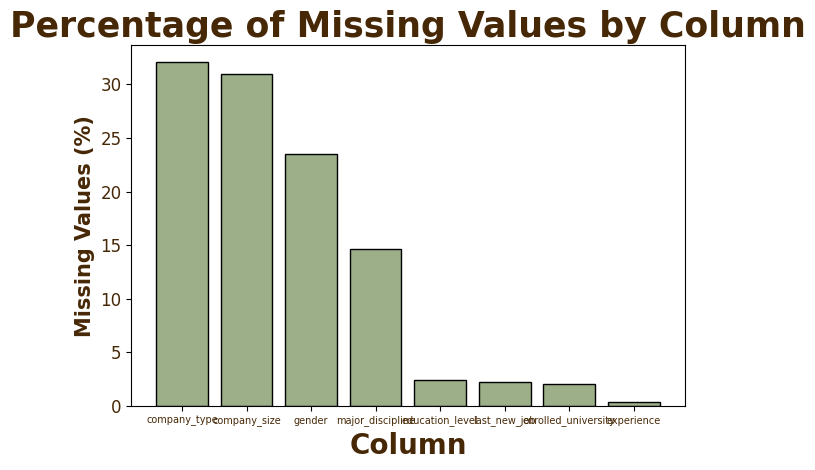

In [88]:
# Percentage of Missing Values by Column
plt.bar(missing_table.index,missing_table['Percentage (%)'],color="#9CAF88",edgecolor="black")
plt.title("Percentage of Missing Values by Column",fontsize=25,color="#472806",fontweight="bold")
plt.xlabel("Column",fontsize=20,color="#472806",fontweight="bold")
plt.ylabel("Missing Values (%)",fontsize=15,color="#472806",fontweight="bold")
plt.xticks(color="#472806",fontsize=7)
plt.yticks(color="#472806",fontsize=12)
plt.tight_layout()
plt.show()

### Remove unuseful columns for prediction & duplicated rows

In [89]:
df = df.drop(columns=['enrollee_id'])
print('Shape after removing enrollee_id:', df.shape)

Shape after removing enrollee_id: (19158, 13)


In [90]:
duplicate_count = df.duplicated().sum()
print('Number of duplicate rows:', duplicate_count)
if duplicate_count > 0:
    df = df.drop_duplicates()
    print('Duplicate rows removed. New shape:', df.shape)
else:
    print('No duplicate rows found in the dataset.')

Number of duplicate rows: 49
Duplicate rows removed. New shape: (19109, 13)


### Separate the Target from the Features

In [91]:
X = df.drop(columns=['target'])
y = df['target']
print('Features :', X.shape)
print('Target :', y.shape)

Features : (19109, 12)
Target : (19109,)


### Split the data [Train/Test]

In [92]:
df = df.dropna(subset=['target'])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20,
    random_state=42,
    stratify=y
)
print('Training set :', X_train.shape)
print('Test set :', X_test.shape)

Training set : (15287, 12)
Test set : (3822, 12)


### Custom preprocessing for ordinal values and city

In [93]:
class CustomPreprocessor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = X.copy()

        experience_map = {'<1': 0,'>20': 21}
        X['experience'] = X['experience'].replace(experience_map)
        X['experience'] = pd.to_numeric(X['experience'],errors='coerce')
        self.experience_median_ = X['experience'].median()

        last_job_mapping = {'never': 0, '>4': 5}
        X['last_new_job'] = X['last_new_job'].replace(last_job_mapping)
        # from str to numeric
        X['last_new_job'] = pd.to_numeric(X['last_new_job'],errors='coerce')
        self.last_job_median_ = X['last_new_job'].median()

        self.education_mapping_ = {'Unknown': 0,'Primary School': 1,'High School': 2, 'Graduate': 3,  'Masters': 4,  'Phd': 5 }

        self.company_size_mapping_ = {'Unknown': 0,'<10': 1,'10/49': 2,'50-99': 3,'100-500': 4,
                                      '500-999': 5,'1000-4999': 6,'5000-9999': 7,'10000+': 8}

        self.city_frequency_ = X['city'].value_counts()
        return self


    def transform(self, X):
        X = X.copy()

        X['experience'] = X['experience'].replace({'<1': 0,'>20': 21})
        X['experience'] = pd.to_numeric( X['experience'], errors='coerce')
        X['experience'] = X['experience'].fillna(self.experience_median_)

        X['last_new_job'] = X['last_new_job'].replace({'never': 0,'>4': 5})
        X['last_new_job'] = pd.to_numeric(X['last_new_job'],errors='coerce')
        X['last_new_job'] = X['last_new_job'].fillna(self.last_job_median_)

        X['education_level'] = X['education_level'].map(self.education_mapping_)

        X['company_size'] = X['company_size'].map(self.company_size_mapping_)

        categorical_cols = ['gender','relevent_experience','enrolled_university','major_discipline','company_type']

        X[categorical_cols] = X[categorical_cols].fillna('Unknown')

        X['city_freq'] = X['city'].map(self.city_frequency_)
        X['city_freq'] = X['city_freq'].fillna(0)
        X = X.drop(columns=['city'])

        return X

### Define columns

In [94]:
categorical_cols = [ 'gender','relevent_experience','enrolled_university','major_discipline', 'company_type']

numeric_cols = ['experience','last_new_job','education_level','company_size','city_freq','city_development_index','training_hours']


### Build the preprocessing pipeline

In [95]:
preprocessor = ColumnTransformer(transformers=[('categorical',OneHotEncoder(drop='first',handle_unknown='ignore'),categorical_cols),

        ('numeric',Pipeline(steps=[
                    (
                        'imputer', SimpleImputer(strategy='median')
                    ),

                    (
                        'scaler', StandardScaler()
                    )
                ]
            ), numeric_cols
        )
    ]
)

### Create the complete Pipeline

In [96]:
pipeline = Pipeline(
    steps=[ (
            'custom_preprocessing', CustomPreprocessor()
        ),
        # Apply encoding and scaling
        (
            'preprocessor', preprocessor
        )
    ]
)

### Fit the Pipeline on TRAIN & apply to test

In [97]:
# pipeline learns rules from train
X_train_processed = pipeline.fit_transform(X_train)

In [98]:
# Test is done
X_test_processed = pipeline.transform(X_test)

### Final Check & Save the cleaned data

In [99]:
print('========== FINAL CHECK ==========')
print('Processed training: ', X_train_processed.shape)
print('Processed test:', X_test_processed.shape)

print('Total missing values in training: ',
      np.isnan(X_train_processed.toarray()).sum()
      if hasattr(X_train_processed, 'toarray')else np.isnan(X_train_processed).sum())

print('Total missing values in test:',
      np.isnan(X_test_processed.toarray()).sum()
      if hasattr(X_test_processed, 'toarray')
      else np.isnan(X_test_processed).sum())

========== FINAL CHECK ==========
Processed training:  (15287, 26)
Processed test: (3822, 26)
Total missing values in training:  0
Total missing values in test: 0


In [100]:
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

X_train_processed_df = pd.DataFrame( X_train_processed.toarray()
    if hasattr(X_train_processed, 'toarray')
    else X_train_processed,
    columns=feature_names)

X_test_processed_df = pd.DataFrame(X_test_processed.toarray()
    if hasattr(X_test_processed, 'toarray')
    else X_test_processed,
    columns=feature_names)

#SAVE
X_train_processed_df.to_csv('/content/aug_train_cleaned.csv',index=False)
X_test_processed_df.to_csv('/content/aug_test_cleaned.csv',index=False)

# SAVE targets
y_train.to_csv('/content/y_train.csv',index=False)
y_test.to_csv('/content/y_test.csv',index=False)


print('Files saved successfully:')
print('- aug_train_cleaned.csv')
print('- aug_test_cleaned.csv')
print('- y_train.csv')
print('- y_test.csv')


Files saved successfully:
- aug_train_cleaned.csv
- aug_test_cleaned.csv
- y_train.csv
- y_test.csv


###Visualization For Data

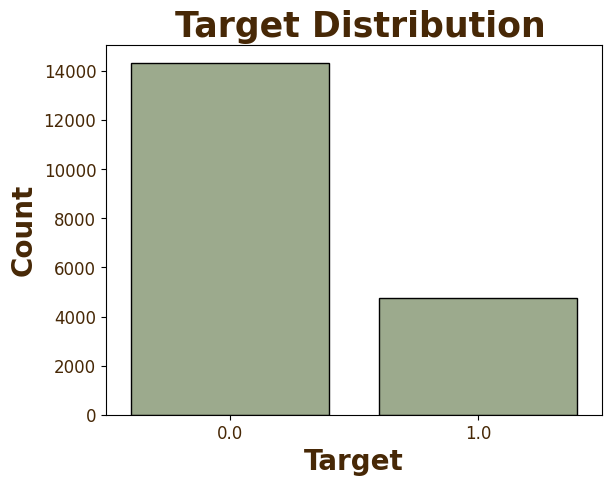

In [101]:
sns.countplot(data=df,x="target",color="#9CAF88",edgecolor="black")
plt.title(" Target Distribution",fontsize=25,color="#472806",fontweight="bold")
#comment--> I used this for adjust style of charts to be fit with presentation
plt.xlabel("Target",fontsize=20,color="#472806",fontweight="bold")
plt.ylabel("Count",fontsize=20,color="#472806",fontweight="bold")
plt.xticks(color="#472806",fontsize=12)
plt.yticks(color="#472806",fontsize=12)
plt.show()

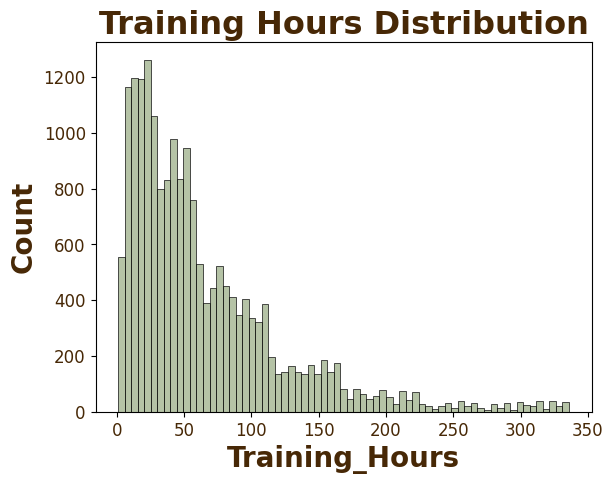

In [102]:
sns.histplot(data=df,x="training_hours",color="#9CAF88",edgecolor="black")
plt.title("Training Hours Distribution",fontsize=23,color="#472806",fontweight="bold")
#comment--> I used this for adjust style of charts to be fit with presentation
plt.xlabel("Training_Hours",fontsize=20,color="#472806",fontweight="bold")
plt.ylabel("Count",fontsize=20,color="#472806",fontweight="bold")
plt.xticks(color="#472806",fontsize=12)
plt.yticks(color="#472806",fontsize=12)
plt.show()

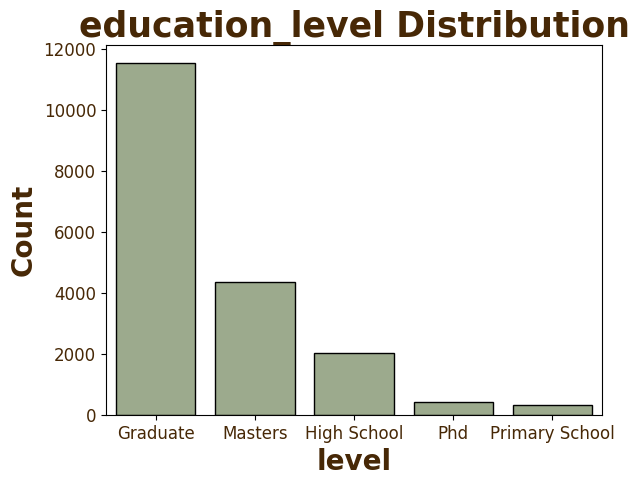

In [103]:
sns.countplot(data=df,x="education_level",color="#9CAF88",edgecolor="black")
plt.title("education_level Distribution",fontsize=25,color="#472806",fontweight="bold")
#comment--> I used this for adjust style of charts to be fit with presentation
plt.xlabel("level",fontsize=20,color="#472806",fontweight="bold")
plt.ylabel("Count",fontsize=20,color="#472806",fontweight="bold")
plt.xticks(color="#472806",fontsize=12)
plt.yticks(color="#472806",fontsize=12)
plt.show()

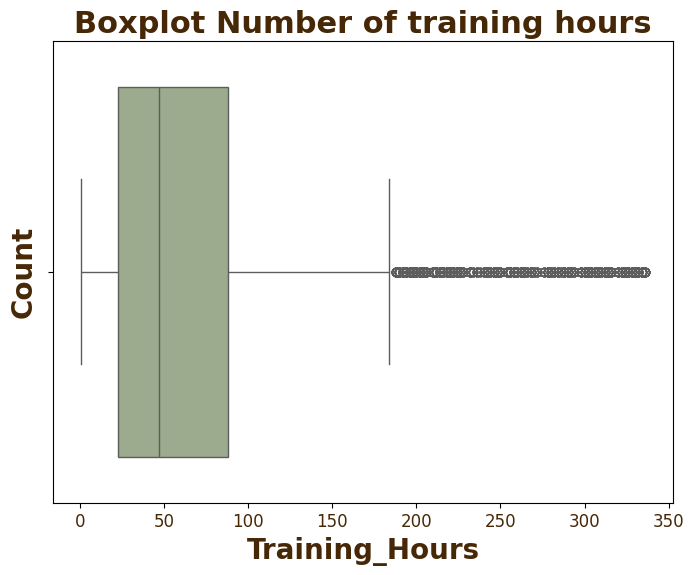

In [104]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df['training_hours'],color="#9CAF88")
plt.xlabel("Training_Hours",fontsize=20,color="#472806",fontweight="bold")
plt.ylabel("Count",fontsize=20,color="#472806",fontweight="bold")
plt.title("Boxplot Number of training hours",fontsize=22,color="#472806",fontweight="bold")
plt.xticks(color="#472806",fontsize=12)
plt.yticks(color="#472806",fontsize=12)
plt.show()

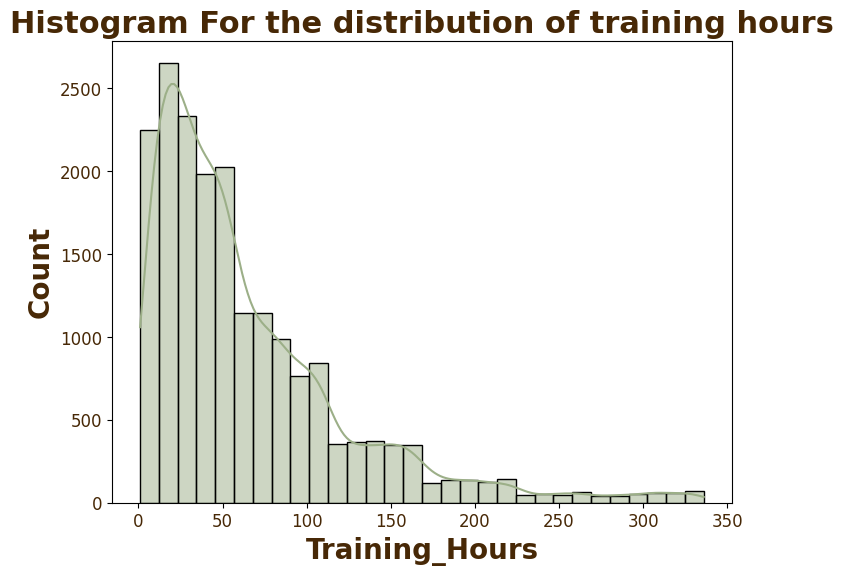

In [105]:
plt.figure(figsize=(8,6))
sns.histplot(df['training_hours'], bins=30, kde=True,color="#9CAF88",edgecolor="black")
plt.title("Histogram For the distribution of training hours",fontsize=22,color="#472806",fontweight="bold")
plt.xlabel("Training_Hours",fontsize=20,color="#472806",fontweight="bold")
plt.ylabel("Count",fontsize=20,color="#472806",fontweight="bold")
plt.xticks(color="#472806",fontsize=12)
plt.yticks(color="#472806",fontsize=12)
plt.show()

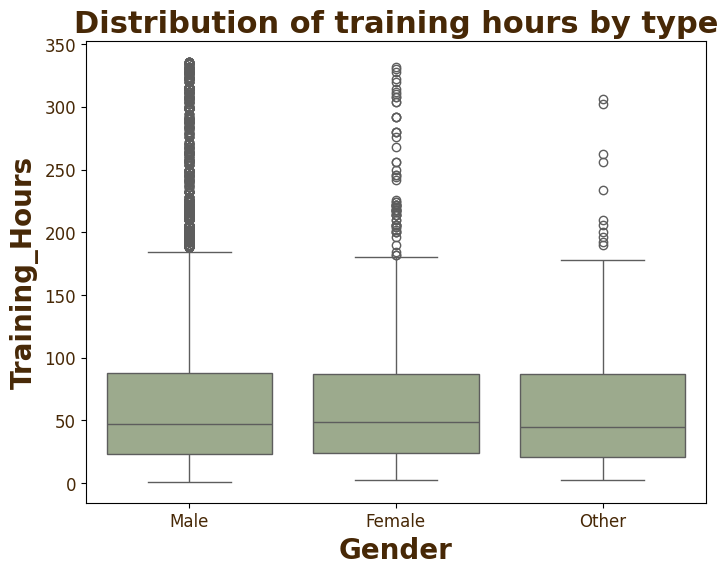

In [106]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df['gender'], y=df['training_hours'],color="#9CAF88")
plt.title("Distribution of training hours by type",fontsize=22,color="#472806",fontweight="bold")
plt.xlabel("Gender",fontsize=20,color="#472806",fontweight="bold")
plt.ylabel("Training_Hours",fontsize=20,color="#472806",fontweight="bold")
plt.xticks(color="#472806",fontsize=12)
plt.yticks(color="#472806",fontsize=12)
plt.show()

In [107]:
print(df.columns)

Index(['city', 'city_development_index', 'gender', 'relevent_experience',
       'enrolled_university', 'education_level', 'major_discipline',
       'experience', 'company_size', 'company_type', 'last_new_job',
       'training_hours', 'target'],
      dtype='object')


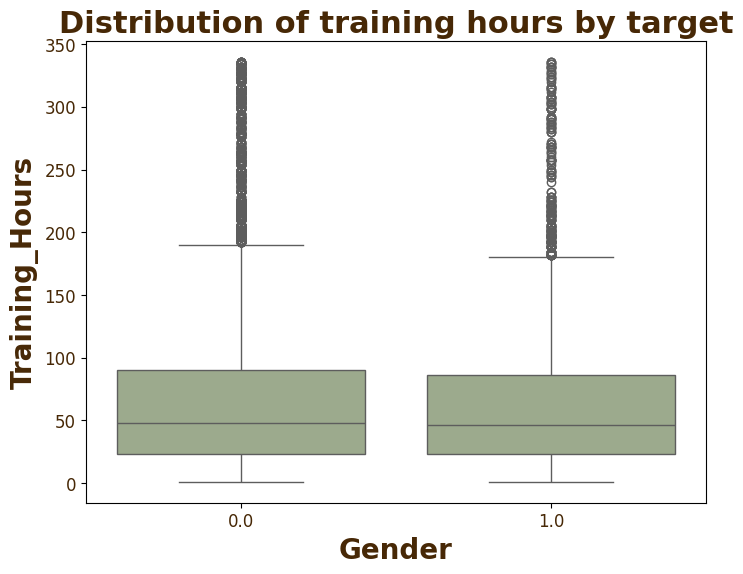

In [108]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df['target'], y=df['training_hours'],color="#9CAF88")
plt.title("Distribution of training hours by target",fontsize=22,color="#472806",fontweight="bold")
plt.xlabel("Gender",fontsize=20,color="#472806",fontweight="bold")
plt.ylabel("Training_Hours",fontsize=20,color="#472806",fontweight="bold")
plt.xticks(color="#472806",fontsize=12)
plt.yticks(color="#472806",fontsize=12)
plt.show()

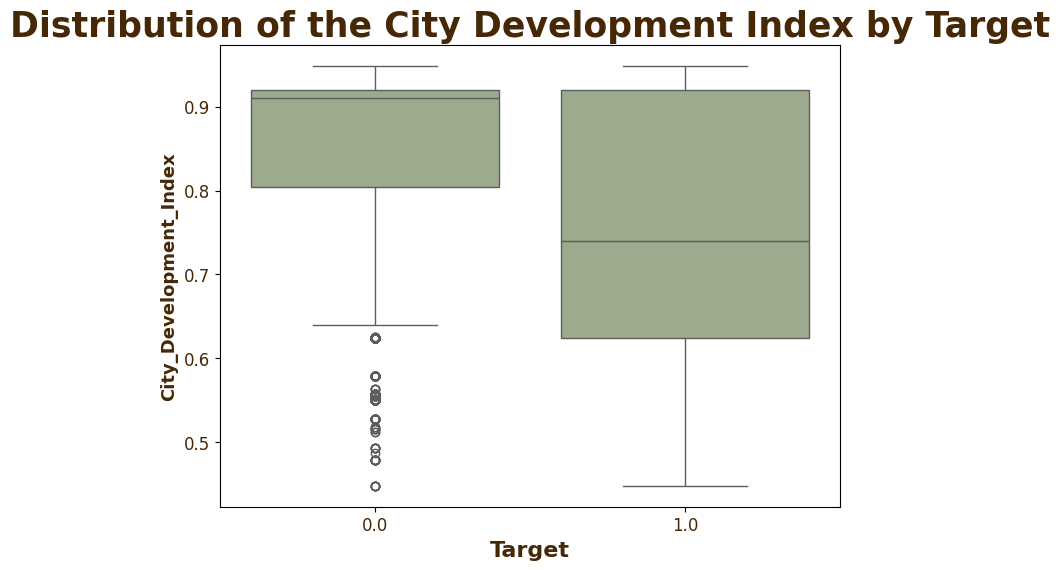

In [109]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df['target'], y=df['city_development_index'],color="#9CAF88")
plt.title("Distribution of the City Development Index by Target",fontsize=25,color="#472806",fontweight="bold")
plt.xlabel("Target",fontsize=16,color="#472806",fontweight="bold")
plt.ylabel("City_Development_Index",fontsize=13,color="#472806",fontweight="bold")
plt.xticks(color="#472806",fontsize=12)
plt.yticks(color="#472806",fontsize=12)
plt.show()


## Train Logistic Regression


In [110]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

log_reg.fit(X_train_processed, y_train)

print('Model trained successfully ')

Model trained successfully 


In [111]:
#predicition of LogisticRegression
y_pred_lr = log_reg.predict(X_test_processed)
y_pred_proba = log_reg.predict_proba(X_test_processed)

print('First 10 predictions:', y_pred_lr[:10])
print('First 10 probabilities (For target = 1) : \n', y_pred_proba[:10])

First 10 predictions: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
First 10 probabilities (For target = 1) : 
 [[0.48162259 0.51837741]
 [0.67994926 0.32005074]
 [0.70329926 0.29670074]
 [0.6126136  0.3873864 ]
 [0.54353317 0.45646683]
 [0.76097893 0.23902107]
 [0.76633102 0.23366898]
 [0.69424819 0.30575181]
 [0.79254277 0.20745723]
 [0.62938512 0.37061488]]


In [112]:
y_pred_lr = log_reg.predict(X_test_processed)
from sklearn.metrics import accuracy_score, f1_score
acc_score = accuracy_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print("Train Score :", log_reg.score(X_train_processed, y_train))
print("Test Score :", log_reg.score(X_test_processed, y_test))
print("F1 Score :", f1)
print("Accuracy Score :", acc_score)

Train Score : 0.7509648721135606
Test Score : 0.7558869701726845
F1 Score : 0.6028097062579821
Accuracy Score : 0.7558869701726845


In [113]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         0.0       0.90      0.76      0.82      2869
         1.0       0.51      0.74      0.60       953

    accuracy                           0.76      3822
   macro avg       0.70      0.75      0.71      3822
weighted avg       0.80      0.76      0.77      3822



Confusion Matrix is : 
 [[2181  688]
 [ 245  708]]



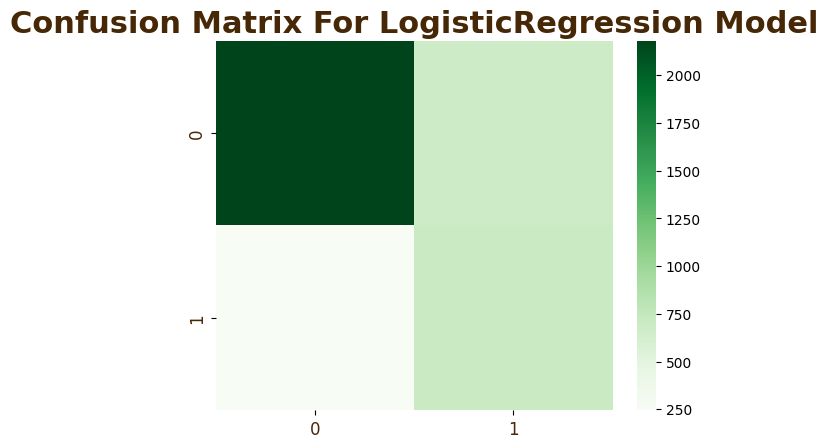

In [114]:
#confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix is : \n",cm)
print()
sns.heatmap(cm,fmt='d',cmap="Greens")
plt.title("Confusion Matrix For LogisticRegression Model",fontsize=22,color="#472806",fontweight="bold")
plt.xticks(color="#472806",fontsize=12)
plt.yticks(color="#472806",fontsize=12)
plt.show()

## Train Random Forest


In [115]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train_processed, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [116]:
y_pred_rf= rf.predict(X_test_processed)
rf.score(X_test_processed,y_test)

0.7723704866562009

In [117]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86      2869
         1.0       0.56      0.40      0.47       953

    accuracy                           0.77      3822
   macro avg       0.69      0.65      0.66      3822
weighted avg       0.75      0.77      0.76      3822



In [118]:
rf2 = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    min_samples_split=10,
    max_depth=14,
    class_weight='balanced',  # FIX: added, same reason as rf
    random_state=42
)
rf2.fit(X_train_processed, y_train)


RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=14, min_samples_split=10, random_state=42)

In [119]:
rf2.score(X_test_processed,y_test)

0.7982731554160125

In [120]:
y_pred2 = rf2.predict(X_test_processed)

# FIX: was printing the old Logistic Regression y_pred by mistake.
# Now correctly evaluates rf2's own predictions.
print(classification_report(y_test, y_pred2))


              precision    recall  f1-score   support

         0.0       0.90      0.83      0.86      2869
         1.0       0.58      0.71      0.64       953

    accuracy                           0.80      3822
   macro avg       0.74      0.77      0.75      3822
weighted avg       0.82      0.80      0.80      3822



Confusion Matrix is : 
 [[2569  300]
 [ 570  383]]



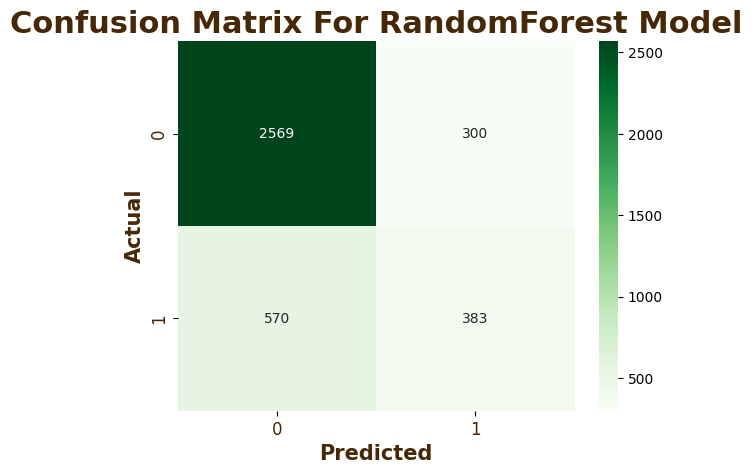

In [121]:
cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix is : \n", cm)
print()
sns.heatmap(cm, annot=True, fmt='d', cmap="Greens")
plt.title("Confusion Matrix For RandomForest Model", fontsize=22, color="#472806", fontweight="bold")
plt.xlabel("Predicted", fontsize=15, color="#472806", fontweight="bold")
plt.ylabel("Actual", fontsize=15, color="#472806", fontweight="bold")
plt.xticks(color="#472806", fontsize=12)
plt.yticks(color="#472806", fontsize=12)
plt.show()

In [122]:
##Saving the most accurate model for WEBSITE 🔅
import joblib
from sklearn.pipeline import Pipeline
import joblib

final_pipeline = Pipeline([('preprocessor', preprocessor),
 ('classifier', rf2)])

joblib.dump(final_pipeline, 'smart_recruitment_model.pkl')

print("Model saved successfully as 'smart_recruitment_model.pkl'")

Model saved successfully as 'smart_recruitment_model.pkl'


In [123]:
# Feature importance for model
imp= pd.DataFrame(rf.feature_importances_, index=feature_names)
imp.head()

,0
categorical__gender_Male,0.016474
categorical__gender_Other,0.002878
categorical__gender_Unknown,0.014272
categorical__relevent_experience_No relevent experience,0.021403
categorical__enrolled_university_Part time course,0.007997


### Top 10 [Bonus]

In [124]:
rank= rf.predict_proba(X_test_processed)[:, 1]
rank_result=X_test.copy()
rank_result['Sucess']=rank
rank_result=rank_result.sort_values(by="Sucess",ascending=False)
rank_result.head(10)

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,Sucess
6952,city_21,0.624,Male,No relevent experience,no_enrollment,High School,NaN,<1,NaN,NaN,never,55,0.98
6426,city_160,0.920,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,NaN,NaN,>4,55,0.94
2232,city_21,0.624,Male,No relevent experience,Full time course,High School,NaN,3,NaN,NaN,never,34,0.93
16304,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,>4,157,0.92
5933,city_21,0.624,NaN,Has relevent experience,no_enrollment,Graduate,STEM,3,50-99,Funded Startup,1,7,0.91
10670,city_21,0.624,Male,Has relevent experience,no_enrollment,Graduate,STEM,5,10/49,Pvt Ltd,never,24,0.91
13931,city_21,0.624,Male,Has relevent experience,no_enrollment,Graduate,STEM,6,10/49,Pvt Ltd,never,22,0.91
8961,city_103,0.920,Male,No relevent experience,no_enrollment,Graduate,STEM,3,NaN,NaN,never,52,0.91
17615,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,2,NaN,NaN,never,24,0.90
214,city_21,0.624,Male,Has relevent experience,no_enrollment,Masters,STEM,3,50-99,Funded Startup,1,88,0.90
